In [2]:
import os
os.getcwd()

'c:\\Users\\moons\\OneDrive\\Documents\\paper_1_final\\polymorphism\\codes'

### Load dataset and keep only inorganic polymorphs

In [3]:
import pandas as pd
df=pd.read_csv(r'../dataset/dataset_polymorphs_icsd.csv')
df=df[(df['is_polymorph']==True) & (df['is_organic']==False)]
df.shape

(28785, 18)

## check number of polymorphs

In [4]:
(df['reduced_formula'].value_counts()>1).sum()

7130

### Naively label prototypes 

In [ ]:
'''
import re
from math import gcd
from functools import reduce
from collections import defaultdict

# ---------------------------------------------------------
# Helper: parse tokens like "Si4+3", "O2-6", "Ti4+1", "Ca2+1"
# ---------------------------------------------------------
TOKEN_RE = re.compile(r"^([A-Z][a-z]?)(?:\d+[+-])?(\d+)$")
COMPACT_RE = re.compile(r"([A-Z][a-z]?)(\d*)")

def gcd_list(vals):
    vals = [int(v) for v in vals if int(v) > 0]
    return reduce(gcd, vals) if vals else 1

def parse_full_formula(s):
    """Parse full_formula strings with oxidation-state annotations.
       Returns {element: count} (reduced)."""
    if not isinstance(s, str):
        return {}
    s = s.strip()
    if not s:
        return {}

    counts = defaultdict(int)

    # Case 1: space-separated tokens like "Si4+3 O2-6"
    if " " in s:
        for tok in s.split():
            tok = tok.strip()
            m = TOKEN_RE.match(tok)
            if m:
                el, cnt = m.group(1), int(m.group(2))
                counts[el] += cnt
            else:
                # fallback: compact-style extraction
                for el, num in COMPACT_RE.findall(tok):
                    counts[el] += int(num) if num else 1
    else:
        # Case 2: compact formula like "Fe2O3" or "CaTiO3"
        for el, num in COMPACT_RE.findall(s):
            counts[el] += int(num) if num else 1

    # Reduce by the GCD so 3:6 → 1:2, etc.
    g = gcd_list(counts.values())
    if g > 1:
        counts = {el: cnt // g for el, cnt in counts.items()}

    return dict(counts)


# ---------------------------------------------------------
# Prototype classifier
# ---------------------------------------------------------
def classify_prototype(full_formula_string):
    counts = parse_full_formula(full_formula_string)
    if not counts:
        return "Other"

    elems = list(counts.keys())
    n = len(elems)
    stoich = sorted(counts[e] for e in elems)

    # Specific prototypes
    if n == 2:
        if stoich == [1, 1]:
            return "Rocksalt/Zincblende/CsCl"
        if stoich == [1, 2]:
            return "Fluorite/Rutile"
        return "Binary"

    if n == 3:
        if stoich == [1, 1, 3]:
            return "Perovskite"
        if stoich == [1, 2, 4]:
            return "Spinel"
        return "Ternary"

    if n == 4:
        return "Quaternary"

    return "Other"
df['prototype'] = df['full_formula'].apply(classify_prototype)
df.to_csv('dataset/icsd_deduped.csv', index=False)
'''

In [5]:
df['prototype'].value_counts()

prototype
Ternary                     10509
Quaternary                   6130
Binary                       3831
Rocksalt/Zincblende/CsCl     2421
Other                        2334
Fluorite/Rutile              1865
Spinel                        901
Perovskite                    794
Name: count, dtype: int64

In [52]:
df.shape

(28785, 18)

## Distribution of structures by prototype

In [5]:
# Create df3 with only polymorphic formulas (reduced_formula count > 1)
vc = df['reduced_formula'].value_counts()
polymorphic_formulas = vc[vc > 1].index
df3 = df[df['reduced_formula'].isin(polymorphic_formulas)]




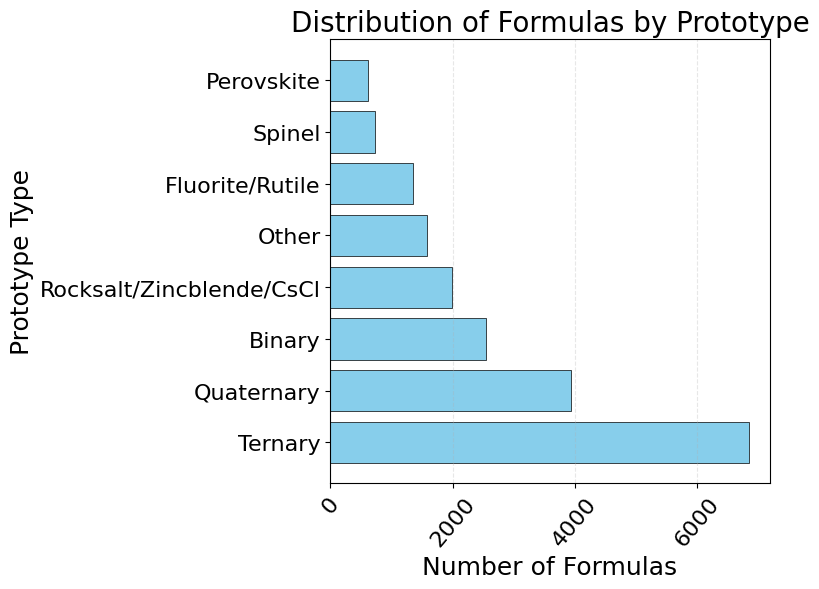

Total prototypes: 8


In [7]:
import matplotlib.pyplot as plt

# Count formulas by prototype
prototype_counts = df3['prototype'].value_counts()

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(prototype_counts.index, prototype_counts.values, color='skyblue', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Number of Formulas', fontsize=18)
ax.set_ylabel('Prototype Type', fontsize=18)
ax.set_title('Distribution of Formulas by Prototype', fontsize=20)
ax.tick_params(axis='both', labelsize=16)
plt.xticks(rotation=50)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
# plt.savefig('ov_icsd.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Total prototypes: {len(prototype_counts)}')


In [6]:
df3['reduced_formula'].value_counts()

reduced_formula
SiO2         196
ZnS          195
CdI2         147
MgAl2O4       97
Mg(FeO2)2     83
            ... 
AlNi3          2
BPO4           2
NdTe2          2
NdTa7O19       2
ZrWC2          2
Name: count, Length: 7130, dtype: int64

## Most frequent element in prototypes

C:\Users\moons\AppData\Local\Temp\ipykernel_6624\2579835230.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3.loc[:, 'element'] = df3['reduced_formula'].apply(lambda x: [str(el) for el in Composition(x).elements])


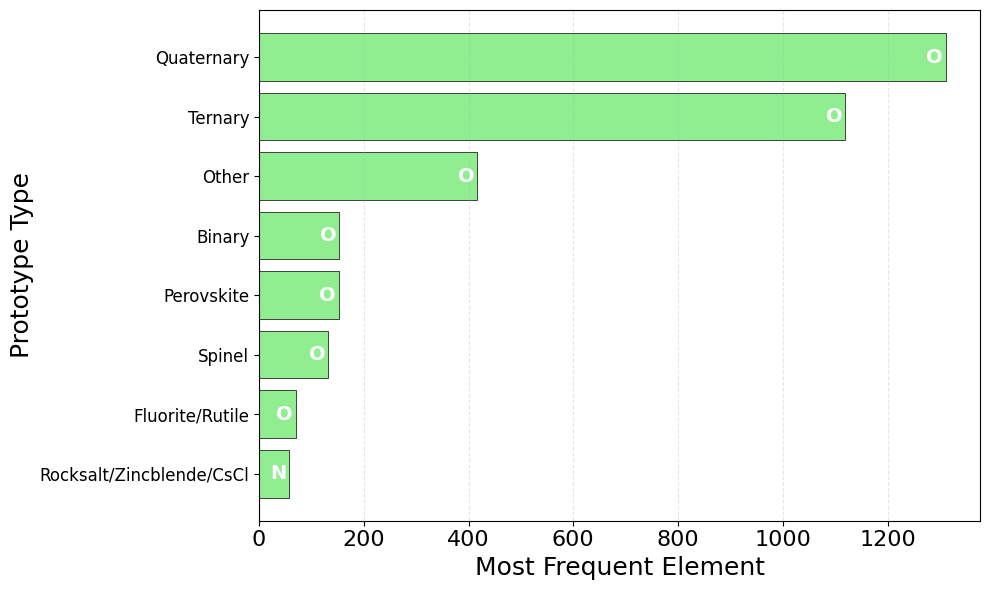

In [8]:
import matplotlib.pyplot as plt
from collections import Counter
from pymatgen.core import Composition

df3.loc[:, 'element'] = df3['reduced_formula'].apply(lambda x: [str(el) for el in Composition(x).elements])
# For each prototype, find the most frequent element across all formulas
prototype_element_data = []

for prototype in df3['prototype'].unique():
    subset = df3[df3['prototype'] == prototype]
    
    # For each unique formula in this prototype, get unique elements
    all_elements = []
    for formula in subset['reduced_formula'].unique():
        formula_rows = subset[subset['reduced_formula'] == formula]
        # Get elements from first row of this formula (all rows have same elements for same formula)
        elements_list = formula_rows['element'].iloc[0]
        unique_elements = set(elements_list)
        all_elements.extend(unique_elements)
    
    # Count most frequent element across all formulas in this prototype
    most_common = Counter(all_elements).most_common(1)
    if most_common:
        element, count = most_common[0]
        prototype_element_data.append((prototype, element, count))

# Sort by count
prototype_element_data.sort(key=lambda x: x[2])

# Prepare data for plotting
prototypes = [x[0] for x in prototype_element_data]
elements = [x[1] for x in prototype_element_data]
counts = [x[2] for x in prototype_element_data]

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(prototypes, counts, color='lightgreen', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Most Frequent Element', fontsize=18)
ax.set_ylabel('Prototype Type', fontsize=18)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add element labels inside bars
for i, (bar, element) in enumerate(zip(bars, elements)):
    width = bar.get_width()
    ax.text(width - 5, bar.get_y() + bar.get_height()/2, element, 
            ha='right', va='center', fontsize=14, fontweight='bold', color='white')

plt.subplots_adjust(left=0.25)
plt.tight_layout()
# plt.savefig('overleaf_icsd_prototype.png', dpi=300, bbox_inches='tight')
plt.show()

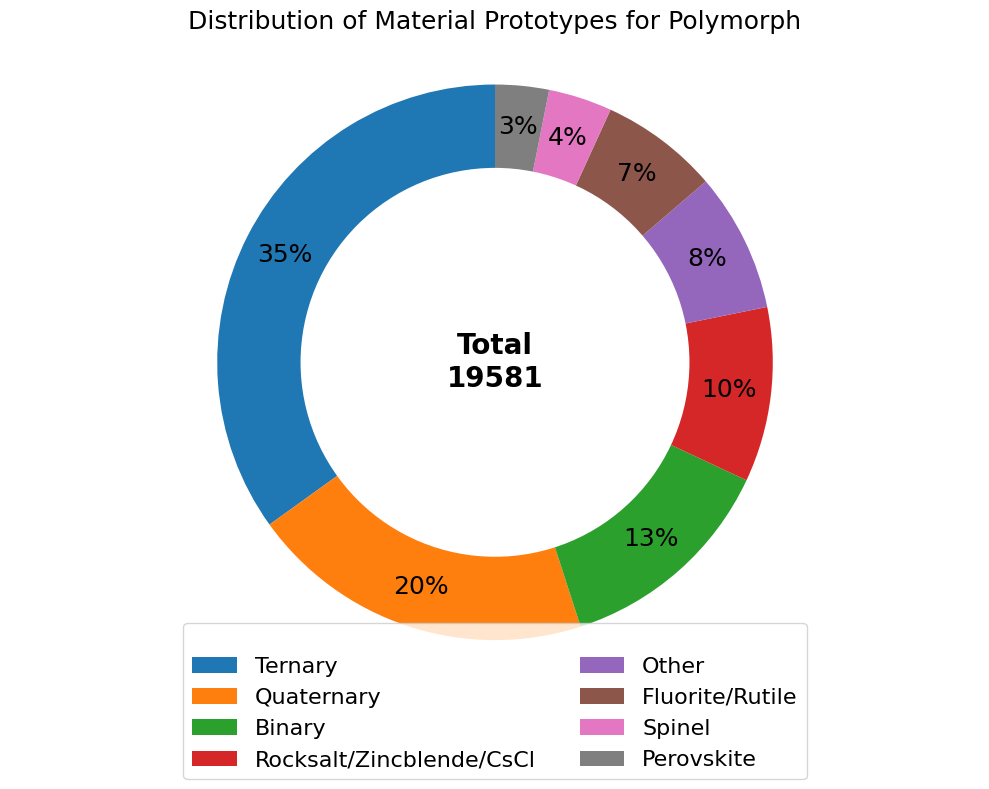

Total structures in polymorphic formulas: 19581

Breakdown by prototype:
Ternary: 6839 (35%)
Quaternary: 3928 (20%)
Binary: 2552 (13%)
Rocksalt/Zincblende/CsCl: 1993 (10%)
Other: 1584 (8%)
Fluorite/Rutile: 1348 (7%)
Spinel: 725 (4%)
Perovskite: 612 (3%)


In [10]:
import matplotlib.pyplot as plt

# Count prototypes in df3
prototype_counts = df3['prototype'].value_counts()
total = len(df3)

# Create color map
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

# Create donut chart
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(prototype_counts.values, 
                                    labels=None,
                                    autopct='%1.0f%%',
                                    startangle=90,
                                    colors=colors[:len(prototype_counts)],
                                    pctdistance=0.85,
                                    textprops={'fontsize': 18})

# Draw circle to make it a donut
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add total in center
ax.text(0, 0, f'Total\n{total}', ha='center', va='center', fontsize=20, fontweight='bold')

# Title
ax.set_title('Distribution of Material Prototypes for Polymorph', fontsize=18, pad=20)

# Add legend below the plot
ax.legend(wedges, prototype_counts.index, title=" ", loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=16)

# Equal aspect ratio ensures circular shape
ax.axis('equal')

plt.tight_layout()
plt.savefig('ov2_icsd.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Total structures in polymorphic formulas: {total}')
print(f'\nBreakdown by prototype:')
for proto, count in prototype_counts.items():
    print(f'{proto}: {count} ({round(count/total*100)}%)')